In [1]:
import pandas as pd
import numpy as np
import os
import sys

In [2]:
df = pd.read_csv('train.csv')

In [3]:
df

,filename,xmin,ymin,xmax,ymax,class
0,0003110600042104_20230711_FL01_esic_esic/00031...,897,115,995,260,Ablagerung
1,0003110600042104_20230711_FL01_esic_esic/00031...,871,0,1029,1633,Riss
2,0003110600042104_20230711_FL01_esic_esic/00031...,897,931,995,1076,Ablagerung
3,0003110600042104_20230711_FL01_esic_esic/00031...,871,0,1029,1633,Riss
4,0003110600042104_20230711_FL01_esic_esic/00031...,897,114,995,259,Ablagerung
...,...,...,...,...,...,...
218019,9004250290042501_20230912_FL01_esic_esic/90042...,11,1270,262,1633,nicht lernen
218020,9004250290042501_20230912_FL01_esic_esic/90042...,11,0,262,562,nicht lernen
218021,9004250290042501_20230912_FL01_esic_esic/90042...,754,0,886,1633,nicht lernen
218022,9004250290042501_20230912_FL01_esic_esic/90042...,11,453,262,1378,nicht lernen


## Columns

In [4]:
# Count of unique filenames
unique_filenames = df['filename'].nunique()
# Percentage of unique filenames
unique_filenames_percentage = (unique_filenames / len(df)) * 100

# Count of unique labels
unique_labels = df['class'].nunique()

print(f"Unique filenames: {unique_filenames}")
print(f"Unique filenames percentage: {unique_filenames_percentage:.2f}%")

print(f"Unique labels: {unique_labels}")

# Total count of filenames per label
filenames_per_label = df['class'].value_counts()
print(f"Total filenames per label:\n{filenames_per_label}")
# Percentage of filenames per label
filenames_per_label_percentage = (filenames_per_label / len(df)) * 100
print(f"Percentage of filenames per label:\n{filenames_per_label_percentage}")

# combine last 2 values into one table
# Count of unique filenames per label
filenames_per_label_unique = df.groupby('class')['filename'].nunique()
print(f"Unique filenames per label:\n{filenames_per_label_unique}")

# Percentage of unique filenames per label
# Count of unique filenames per label
# Count of unique filenames per label
filenames_per_label_percentage_unique = (filenames_per_label_unique / df['filename'].nunique()) * 100
print(f"Percentage of unique filenames per label:\n{filenames_per_label_percentage_unique}")

# Create new dataframe with the above values
df_summary = pd.DataFrame({
    'Total Filenames': filenames_per_label,
    'Percentage of Filenames': filenames_per_label_percentage,
    'Unique Filenames': filenames_per_label_unique,
    'Percentage of Unique Filenames': filenames_per_label_percentage_unique
})

Unique filenames: 91599
Unique filenames percentage: 42.01%
Unique labels: 11
Total filenames per label:
class
Ablagerung        53108
Materialabtrag    43783
Lageabweichung    36235
Riss              19647
Muffenschaden     16800
Anschluss         15397
Wurzel            13830
nicht lernen      10620
Hindernis          6377
Bruch              1131
Deformation        1096
Name: count, dtype: int64
Percentage of filenames per label:
class
Ablagerung        24.358786
Materialabtrag    20.081734
Lageabweichung    16.619730
Riss               9.011393
Muffenschaden      7.705574
Anschluss          7.062067
Wurzel             6.343338
nicht lernen       4.871023
Hindernis          2.924907
Bruch              0.518750
Deformation        0.502697
Name: count, dtype: float64
Unique filenames per label:
class
Ablagerung        28115
Anschluss         12129
Bruch               852
Deformation         951
Hindernis          4617
Lageabweichung    26532
Materialabtrag    24273
Muffenschaden     14

In [5]:
df_summary = df_summary.reset_index()
df_summary.columns = ['Class', 'Total Filenames', 'Percentage of Filenames', 'Unique Filenames', 'Percentage of Unique Filenames']
df_summary = df_summary.set_index('Class')
df_summary = df_summary.sort_values(by='Total Filenames', ascending=False)
df_summary.to_csv('summary.csv')
print(df_summary)

                Total Filenames  Percentage of Filenames  Unique Filenames  \
Class                                                                        
Ablagerung                53108                24.358786             28115   
Materialabtrag            43783                20.081734             24273   
Lageabweichung            36235                16.619730             26532   
Riss                      19647                 9.011393             11499   
Muffenschaden             16800                 7.705574             14559   
Anschluss                 15397                 7.062067             12129   
Wurzel                    13830                 6.343338              9682   
nicht lernen              10620                 4.871023              8469   
Hindernis                  6377                 2.924907              4617   
Bruch                      1131                 0.518750               852   
Deformation                1096                 0.502697        

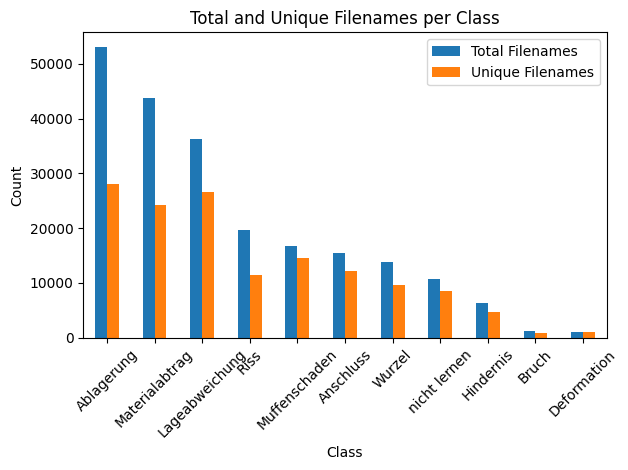

In [6]:

# Plot the data
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

fig, ax = plt.subplots()
df_summary[['Total Filenames', 'Unique Filenames']].plot(kind='bar', ax=ax)
ax.set_title('Total and Unique Filenames per Class')
ax.set_xlabel('Class')
ax.set_ylabel('Count')
ax.set_xticklabels(df_summary.index, rotation=45)
ax.legend(['Total Filenames', 'Unique Filenames'])
plt.tight_layout()
plt.savefig('summary.png')
plt.show()


In [7]:


# Redo the same plot using plotly
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = 'browser'
# Create a bar plot using Plotly    
fig = go.Figure()
fig.add_trace(go.Bar(
    x=df_summary.index,
    y=df_summary['Total Filenames'],
    name='Total Filenames',
    marker_color='blue'
))
fig.add_trace(go.Bar(
    x=df_summary.index,
    y=df_summary['Unique Filenames'],
    name='Unique Filenames',
    marker_color='orange'
))
# Update layout

fig.update_layout(
    
    title='Total and Unique Filenames per Class',
    xaxis_title='Class',
    yaxis_title='Count',
    barmode='group',
    xaxis_tickangle=-45,
    xaxis=dict(
        tickmode='array',
        tickvals=df_summary.index,
        ticktext=df_summary.index
    ),
    yaxis=dict(
        tickmode='linear',
        dtick=1
    ),
    legend=dict(
        x=0.8,
        y=1.2,
        traceorder='normal',
        orientation='h'
    ),
    margin=dict(l=40, r=40, t=40, b=40),
    height=600,
    width=800,
    paper_bgcolor='white',
    plot_bgcolor='white',
    font=dict(
        family="Arial, sans-serif",
        size=12,
        color="black"
    ),
    title_font=dict(
        family="Arial, sans-serif",
        size=16,
        color="black"
    ),
    xaxis_title_font=dict(
        family="Arial, sans-serif",
        size=14,
        color="black"
    ),
)
# Show the plot
fig.show()
# Save the plot as an HTML file
fig.write_html('summary_plotly.html')

Gtk-Message: 19:13:00.878: Failed to load module "xapp-gtk3-module"
Gtk-Message: 19:13:00.878: Not loading module "atk-bridge": The functionality is provided by GTK natively. Please try to not load it.
[42556, Main Thread] WARNING: GTK+ module /snap/firefox/6019/gnome-platform/usr/lib/gtk-2.0/modules/libcanberra-gtk-module.so cannot be loaded.
GTK+ 2.x symbols detected. Using GTK+ 2.x and GTK+ 3 in the same process is not supported.: 'glib warning', file /build/firefox/parts/firefox/build/toolkit/xre/nsSigHandlers.cpp:201

(firefox_firefox:42556): Gtk-WARNING **: 19:13:00.960: GTK+ module /snap/firefox/6019/gnome-platform/usr/lib/gtk-2.0/modules/libcanberra-gtk-module.so cannot be loaded.
GTK+ 2.x symbols detected. Using GTK+ 2.x and GTK+ 3 in the same process is not supported.
Gtk-Message: 19:13:00.960: Failed to load module "canberra-gtk-module"
[42556, Main Thread] WARNING: GTK+ module /snap/firefox/6019/gnome-platform/usr/lib/gtk-2.0/modules/libcanberra-gtk-module.so cannot be load

In [ ]:
# Compare abs(xmax - xmin) across duplicate filenames
# Get the unique filenames
unique_filenames = df['filename'].unique()
# Create a new dataframe to store the results
df_duplicates = pd.DataFrame(columns=['filename', 'abs_diff'])
# Loop through each unique filename
for filename in unique_filenames:
    # Get the rows with the same filename
    df_filename = df[df['filename'] == filename]
    # Check if there are duplicates
    if len(df_filename) > 1:
        # Calculate the absolute difference between xmax and xmin
        abs_diff = abs(df_filename['xmax'].max() - df_filename['xmin'].min())
        # Append the result to the dataframe
        df_duplicates = pd.concat([df_duplicates, pd.DataFrame({'filename': [filename], 'abs_diff': [abs_diff]})], ignore_index=True)
# Sort the dataframe by abs_diff
df_duplicates = df_duplicates.sort_values(by='abs_diff', ascending=False)
# Save the dataframe to a CSV file
df_duplicates.to_csv('duplicates.csv', index=False)
# Print the top 10 duplicates
print(df_duplicates.head(10))
# Plot the abs_diff values
fig, ax = plt.subplots(figsize=(12, 6))
plt.bar(range(len(df_duplicates)), df_duplicates['abs_diff'])
ax.set_title('Absolute Difference between xmax and xmin for Duplicate Filenames')
ax.set_xlabel('Filename')
ax.set_ylabel('Absolute Difference')
ax.set_xticks(range(len(df_duplicates)))
ax.set_xticklabels(df_duplicates['filename'], rotation=90)
plt.tight_layout()
plt.savefig('duplicates.png')